
PHASE 1 - STEP 1: LOAD DATASET


In [154]:
import pandas as pd

In [155]:
# Load dataset
df = pd.read_csv('../data/solar_data_large.csv')

In [156]:
# Show first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
0        5.641943     1329.246469        3.323116      26.650996   
1        7.781800     1243.154639        3.107887      29.500706   
2        6.874096      961.659119        2.404148      23.633972   
3        6.313267     1189.140253        2.972851      28.534219   
4        4.541925      984.154617        2.460387      26.319659   

   monthly_generation_kwh  
0              410.834996  
1              484.833212  
2              335.039358  
3              402.728135  
4              273.893433  


In [157]:
# Dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sunlight_hours          100000 non-null  float64
 1   roof_area_sqft          100000 non-null  float64
 2   system_size_kw          100000 non-null  float64
 3   temperature_c           100000 non-null  float64
 4   monthly_generation_kwh  100000 non-null  float64
dtypes: float64(5)
memory usage: 3.8 MB
None


In [158]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
count   100000.000000   100000.000000   100000.000000  100000.000000   
mean         5.996950     1202.128185        3.005320      30.010241   
std          1.170483      461.906753        1.154767       5.862191   
min          3.384974      400.007646        1.000019      16.053056   
25%          4.998218      801.148079        2.002870      25.020765   
50%          5.995572     1203.010090        3.007525      30.056940   
75%          6.998094     1600.658082        4.001645      35.005641   
max          8.626939     1999.983016        4.999958      43.201534   

       monthly_generation_kwh  
count           100000.000000  
mean               404.028282  
std                179.974082  
min                 53.833115  
25%                256.875586  
50%                386.204053  
75%                527.894282  
max               1082.669803  


In [159]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sunlight_hours            0
roof_area_sqft            0
system_size_kw            0
temperature_c             0
monthly_generation_kwh    0
dtype: int64


In [160]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['sunlight_hours', 'roof_area_sqft', 'system_size_kw', 'temperature_c',
       'monthly_generation_kwh'],
      dtype='object')



PHASE 1 - STEP 2: PREPROCESSING


In [161]:
# Check data types
print(df.dtypes)

sunlight_hours            float64
roof_area_sqft            float64
system_size_kw            float64
temperature_c             float64
monthly_generation_kwh    float64
dtype: object


In [162]:
df["efficiency"] = df["monthly_generation_kwh"] / df["system_size_kw"]

In [163]:
df["sun_temp_interaction"] = df["sunlight_hours"] * df["temperature_c"]
df["area_sun_interaction"] = df["roof_area_sqft"] * df["sunlight_hours"]

In [164]:
print(df.head())

   sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
0        5.641943     1329.246469        3.323116      26.650996   
1        7.781800     1243.154639        3.107887      29.500706   
2        6.874096      961.659119        2.404148      23.633972   
3        6.313267     1189.140253        2.972851      28.534219   
4        4.541925      984.154617        2.460387      26.319659   

   monthly_generation_kwh  efficiency  sun_temp_interaction  \
0              410.834996  123.629441            150.363412   
1              484.833212  156.000934            229.568588   
2              335.039358  139.358885            162.462188   
3              402.728135  135.468675            180.144141   
4              273.893433  111.321302            119.541923   

   area_sun_interaction  
0           7499.533355  
1           9673.980365  
2           6610.536972  
3           7507.359783  
4           4469.956674  


In [165]:
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df, df.columns)

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99756 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sunlight_hours          99756 non-null  float64
 1   roof_area_sqft          99756 non-null  float64
 2   system_size_kw          99756 non-null  float64
 3   temperature_c           99756 non-null  float64
 4   monthly_generation_kwh  99756 non-null  float64
 5   efficiency              99756 non-null  float64
 6   sun_temp_interaction    99756 non-null  float64
 7   area_sun_interaction    99756 non-null  float64
dtypes: float64(8)
memory usage: 6.8 MB



PHASE 1 - STEP 3: FEATURE SETUP


In [167]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df[[
    "sunlight_hours", 
    "roof_area_sqft", 
    "system_size_kw", 
    "temperature_c",
    "sun_temp_interaction"
    ]]

y = df["monthly_generation_kwh"]

In [169]:
# Check shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (99756, 6)
Target shape: (99756,)


In [170]:
# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (79804, 6)
Testing data: (19952, 6)


In [171]:
print("\nSample features:")
print(X.head())


Sample features:
   sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
0        5.641943     1329.246469        3.323116      26.650996   
1        7.781800     1243.154639        3.107887      29.500706   
2        6.874096      961.659119        2.404148      23.633972   
3        6.313267     1189.140253        2.972851      28.534219   
4        4.541925      984.154617        2.460387      26.319659   

   sun_temp_interaction  area_sun_interaction  
0            150.363412           7499.533355  
1            229.568588           9673.980365  
2            162.462188           6610.536972  
3            180.144141           7507.359783  
4            119.541923           4469.956674  



PHASE 1 - STEP 4: MODEL TRAINING


In [172]:
from sklearn.ensemble import RandomForestRegressor

In [173]:
# Initialize model
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [174]:
# Train model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [175]:
# Make predictions on test data
y_pred = model.predict(X_test)

In [176]:
# Show sample predictions
print("\nSample Predictions:")
print(y_pred[:10])


Sample Predictions:
[293.34654446 176.20999061 798.88112956 227.17152539 287.7791092
 174.90693292 443.51491369 682.31510813 573.43728407 512.84911077]


In [177]:
import numpy as np

print("\nPrediction range:")
print("Min:", np.min(y_pred))
print("Max:", np.max(y_pred))


Prediction range:
Min: 87.16546763575747
Max: 892.5977190781315



PHASE 1 - STEP 5: EVALUATION


In [178]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [179]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [180]:
# Print results
print("Model Evaluation:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

Model Evaluation:
MAE  : 30.01
RMSE : 41.78
R2   : 0.9456


PHASE 1 - STEP 6: FEATURE IMPORTANCE


In [181]:
import pandas as pd

In [182]:
# Get feature importance
importances = model.feature_importances_

In [183]:
# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

In [184]:
# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

In [185]:
# Display
print(feature_importance_df)

                Feature  Importance
5  area_sun_interaction    0.963456
3         temperature_c    0.009831
4  sun_temp_interaction    0.009483
0        sunlight_hours    0.007632
1        roof_area_sqft    0.004844
2        system_size_kw    0.004754


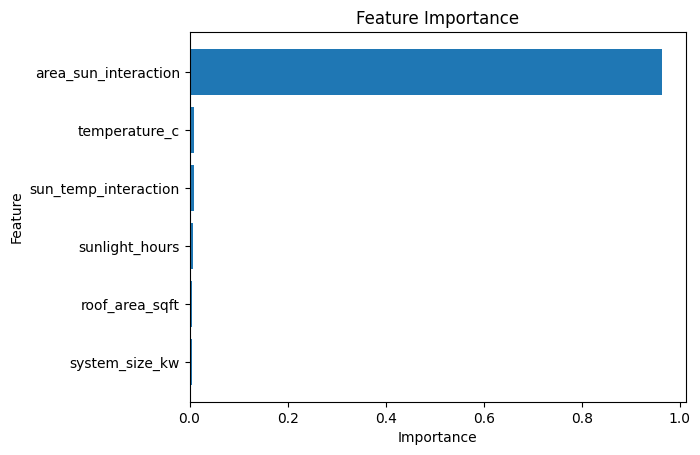

In [186]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()